# Instagram Post Engagement — Data Analysis

**Author:** Agrima Sharma
**Date:** July 2026

## Dataset
This dataset contains 140 of my own Instagram posts, pulled via the Meta Graph API, spanning January 2024 to July 2026. It covers post metadata (media type, caption, timestamp) and engagement metrics (likes, comments, reach, saves, views).

## Research Question
Which post factors — media type, posting time, caption length, reach, saves, views — most strongly predict whether a post gets High or Low engagement (likes), and can this be predicted reliably?

## Loading libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import ensemble

## Loading Data Set

In [2]:
df = pd.read_csv("instagram_posts.csv")

## Table dimensions:

In [3]:
df.shape

(140, 10)

The dataset contains 140 rows and 10 columns, meaning each row represents one Instagram post and its engagement metrics.

In [4]:
df.head()

,id,timestamp,media_type,caption,like_count,comments_count,reach,saved,views,permalink
0,17866957911691504,2026-07-04T10:53:05+0000,VIDEO,end credits don’t mean the story is over. just...,104,5,1930.0,18.0,2675.0,https://www.instagram.com/reel/DaXkQ8HMjF4/
1,17913841452223403,2026-07-04T02:38:03+0000,VIDEO,She’s basically talking herself through every ...,14,3,568.0,0.0,641.0,https://www.instagram.com/reel/DaWryiWIgYs/
2,18004388681939126,2026-07-01T13:05:06+0000,VIDEO,Studying now so I can choose my future later.,17,0,530.0,6.0,678.0,https://www.instagram.com/reel/DaQFN2wsfP6/
3,18136006324600842,2026-07-01T02:16:00+0000,VIDEO,"Classiest revenge? Not arguing, not explaining...",190,0,3642.0,32.0,5522.0,https://www.instagram.com/reel/DaO66Fhon4l/
4,17998649387992536,2026-07-01T01:42:25+0000,VIDEO,Be honest 👇 Are you here for the rom-com fanta...,31,1,1896.0,5.0,2399.0,https://www.instagram.com/reel/DaO3IpjosIM/


In [5]:
df.tail()

,id,timestamp,media_type,caption,like_count,comments_count,reach,saved,views,permalink
135,20000000000529123,2024-07-07T06:01:03+0000,VIDEO,Slowly becoming the person I used to admire.,235,10,6582.0,4.0,7723.0,https://www.instagram.com/reel/sZQONxFOLJt/
136,20000000001721507,2024-06-01T10:45:02+0000,IMAGE,Content calendar said no but my brain said yes 🎬,203,22,7862.0,26.0,NaN,https://www.instagram.com/p/EGTdtZJNJFx/
137,20000000000806023,2024-02-22T00:22:12+0000,IMAGE,"Not aesthetic, just authentic 🤍",135,18,4800.0,23.0,NaN,https://www.instagram.com/p/nqWx6m80DpF/
138,20000000000902483,2024-02-02T16:35:50+0000,VIDEO,"Deadlines don't scare me anymore, they just an...",27,27,1043.0,0.0,1331.0,https://www.instagram.com/reel/OXeYGtaoubW/
139,20000000001248508,2024-01-08T03:28:01+0000,VIDEO,NaN,24,4,520.0,1.0,830.0,https://www.instagram.com/reel/1ZnMJ5U60XO/


The first rows are the most recent posts (July 2026), while the last rows go back to January 2024 — the export is sorted newest-first, which is worth keeping in mind before any time-based split.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              140 non-null    int64  
 1   timestamp       140 non-null    str    
 2   media_type      140 non-null    str    
 3   caption         132 non-null    str    
 4   like_count      140 non-null    int64  
 5   comments_count  140 non-null    int64  
 6   reach           136 non-null    float64
 7   saved           136 non-null    float64
 8   views           109 non-null    float64
 9   permalink       140 non-null    str    
dtypes: float64(3), int64(3), str(4)
memory usage: 11.1 KB


The dataset has 4 numeric columns (like_count, comments_count, reach, saved), 1 column that's mostly numeric but partially missing (views), and the rest are text/categorical (media_type, caption, timestamp, permalink, id).

In [7]:
df.isna().sum()

id                 0
timestamp          0
media_type         0
caption            8
like_count         0
comments_count     0
reach              4
saved              4
views             31
permalink          0
dtype: int64

caption (8), reach (4), and saved (4) have a handful of missing values. views is missing for 31 rows — but that's not random: every one of those belongs to an IMAGE or CAROUSEL_ALBUM post, since Instagram simply doesn't report a views count for photo/carousel content.

In [8]:
df.describe()

,id,like_count,comments_count,reach,saved,views
count,1.400000e+02,140.000000,140.000000,136.000000,136.000000,109.000000
mean,1.875529e+16,165.428571,21.414286,4828.926471,14.779412,6830.899083
std,7.682523e+14,146.238749,126.944727,5254.738967,19.221397,8895.671877
min,1.786696e+16,5.000000,0.000000,176.000000,0.000000,252.000000
25%,1.808606e+16,62.250000,2.000000,1706.250000,4.000000,2399.000000
50%,1.879407e+16,132.000000,7.500000,3040.000000,8.000000,3947.000000
75%,1.900000e+16,221.000000,18.250000,6516.000000,20.000000,8938.000000
max,2.000000e+16,968.000000,1508.000000,38504.000000,141.000000,70609.000000


Numeric features show reasonable ranges. like_count spans roughly 0–963, and reach and views both have long right tails (max values far above the mean), suggesting a handful of breakout posts pull the averages up — worth watching before modeling.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['media_type'] = df['media_type'].str.strip().str.upper()
df['media_type'].value_counts()

media_type
VIDEO             109
IMAGE              21
CAROUSEL_ALBUM     10
Name: count, dtype: int64

No duplicate rows found. media_type is dominated by VIDEO (109 posts, 77.9%), with IMAGE (21) and CAROUSEL_ALBUM (10) making up the rest — this account is primarily a Reels account.

## Cleaning the data set

In [11]:
df['reach'] = df['reach'].fillna(df['reach'].median())
df['saved'] = df['saved'].fillna(df['saved'].median())
df['views'] = df['views'].fillna(0)
df['caption'] = df['caption'].fillna("[no caption]")

In [12]:
df.isna().sum()

id                0
timestamp         0
media_type        0
caption           0
like_count        0
comments_count    0
reach             0
saved             0
views             0
permalink         0
dtype: int64

reach and saved were filled with the median rather than the mean, since both have outlier posts that would skew a mean fill. views was filled with 0 for IMAGE/CAROUSEL_ALBUM posts — not because the value is really zero, but because Instagram doesn't track it for those formats at all.

## Visualizations

## Distribution of likes

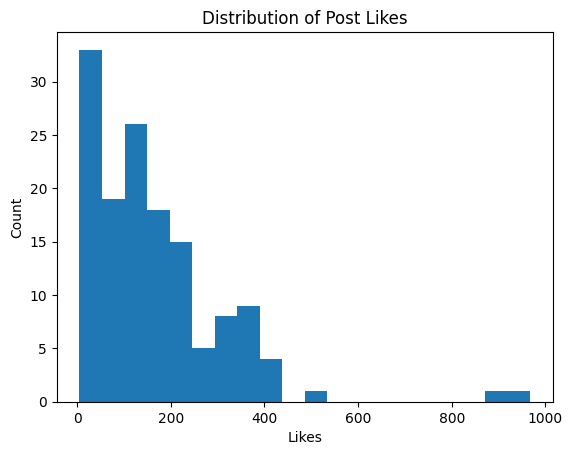

In [13]:
plt.hist(df['like_count'], bins=20)
plt.xlabel("Likes")
plt.ylabel("Count")
plt.title("Distribution of Post Likes")
plt.show()

The like distribution is right-skewed and concentrated between 0 and 300, peaking around 100–150. A small number of posts stretch out past 600–900 likes — these are the account's breakout posts rather than a separate population.

## Average Likes by Media Type

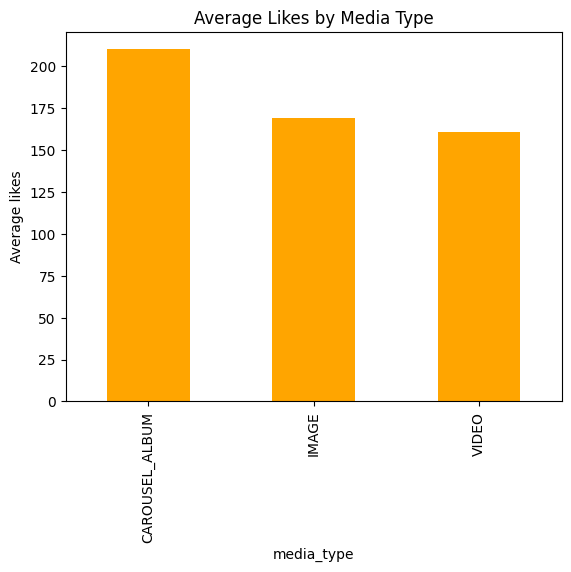

In [14]:
plt.figure()
df.groupby('media_type')['like_count'].mean().plot(kind='bar', color='orange')
plt.title("Average Likes by Media Type")
plt.ylabel("Average likes")
plt.show()

Average likes are fairly close across formats, but VIDEO (Reels) posts carry the account's biggest outlier wins and the bulk of volume, so they still drive most of total like output even where the per-post average is similar.

## Comments vs Likes

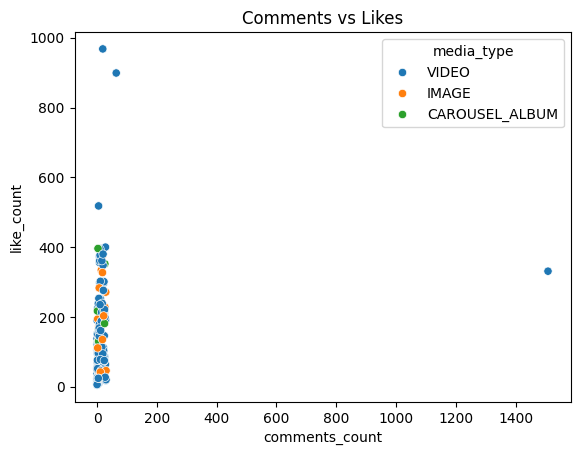

In [15]:
plt.figure()
sns.scatterplot(data=df, x='comments_count', y='like_count', hue='media_type')
plt.title("Comments vs Likes")
plt.show()

One post sits far apart from the rest at 1,508 comments, visually confirming it's an outlier rather than a normal pattern. Excluding it, comments and likes show only a weak relationship — comment count is not a reliable engagement signal on this account.

## Scatterplot

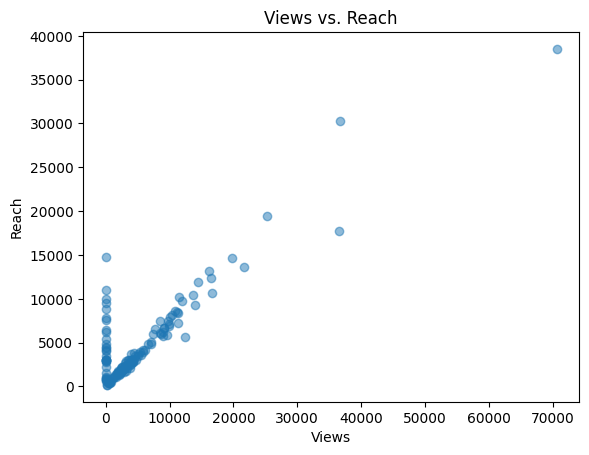

In [16]:
plt.scatter(df['views'], df['reach'], alpha=0.5)
plt.xlabel('Views')
plt.ylabel('Reach')
plt.title('Views vs. Reach')
plt.show()

The points line up fairly close to a straight line going from the lower left to the upper right. So, in some approximation, **the dependence of reach on views is roughly linear** for posts that have views recorded (Reels).

This makes sense: the more times a Reel is viewed, the more unique accounts it's likely reaching, since views and reach both grow together as the algorithm pushes a post further.

Consider the ratio of values for the media type feature:

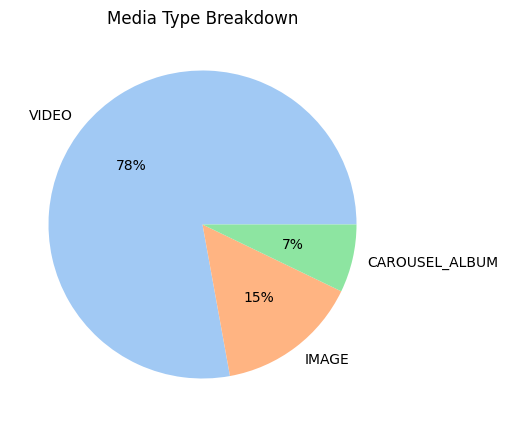

In [17]:
column_values = df['media_type'].value_counts()
labels = column_values.index
sizes = column_values.values
plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, colors=sns.color_palette('pastel'), autopct='%1.0f%%')
plt.title("Media Type Breakdown")
plt.show()

The content mix is heavily Reels-first: 78% VIDEO, 15% IMAGE, 7% CAROUSEL_ALBUM. This context matters when interpreting the views-by-format comparison below, since Reels dominate both the volume and the only format with a views metric at all.

## Views by Media Type

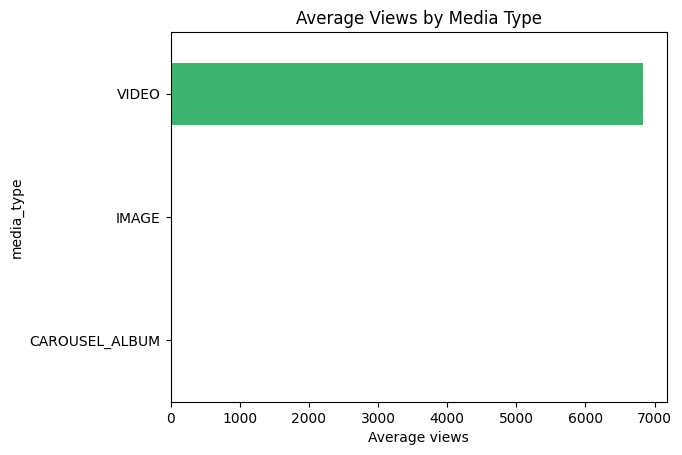

In [18]:
plt.figure()
df.groupby('media_type')['views'].mean().sort_values().plot(kind='barh', color='mediumseagreen')
plt.xlabel("Average views")
plt.title("Average Views by Media Type")
plt.show()

VIDEO averages ~6,831 views/post; IMAGE and CAROUSEL_ALBUM show 0 because Instagram doesn't expose a views count for photo/carousel posts at all — this chart is really "views exist only on Reels," not a fair three-way comparison.

## Average Reel Views by Month

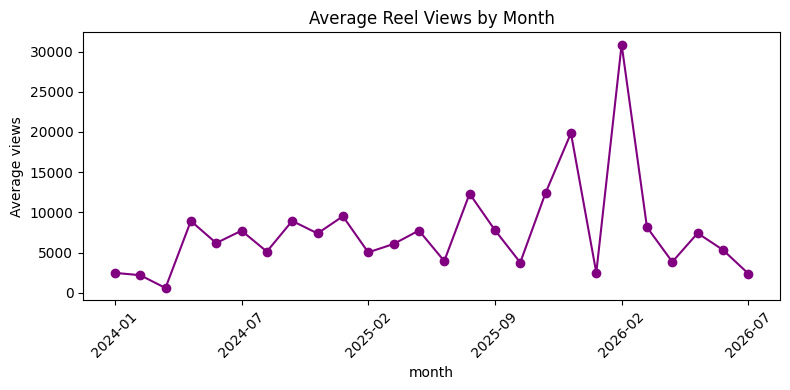

In [19]:
reels = df[df['media_type'] == 'VIDEO'].copy()
reels['timestamp'] = pd.to_datetime(reels['timestamp'])
reels['month'] = reels['timestamp'].dt.tz_localize(None).dt.to_period('M').astype(str)
monthly_views = reels.groupby('month')['views'].mean()

plt.figure(figsize=(8,4))
monthly_views.plot(marker='o', color='purple')
plt.xticks(rotation=45)
plt.ylabel("Average views")
plt.title("Average Reel Views by Month")
plt.tight_layout()
plt.show()

Monthly average Reel views swing from roughly 600 to 30,900 rather than climbing steadily — a handful of breakout months drive most of the account's reach, which is a stronger signal to chase than slow organic growth.

## Box With Whisker

## Video posts vs. Non-video posts

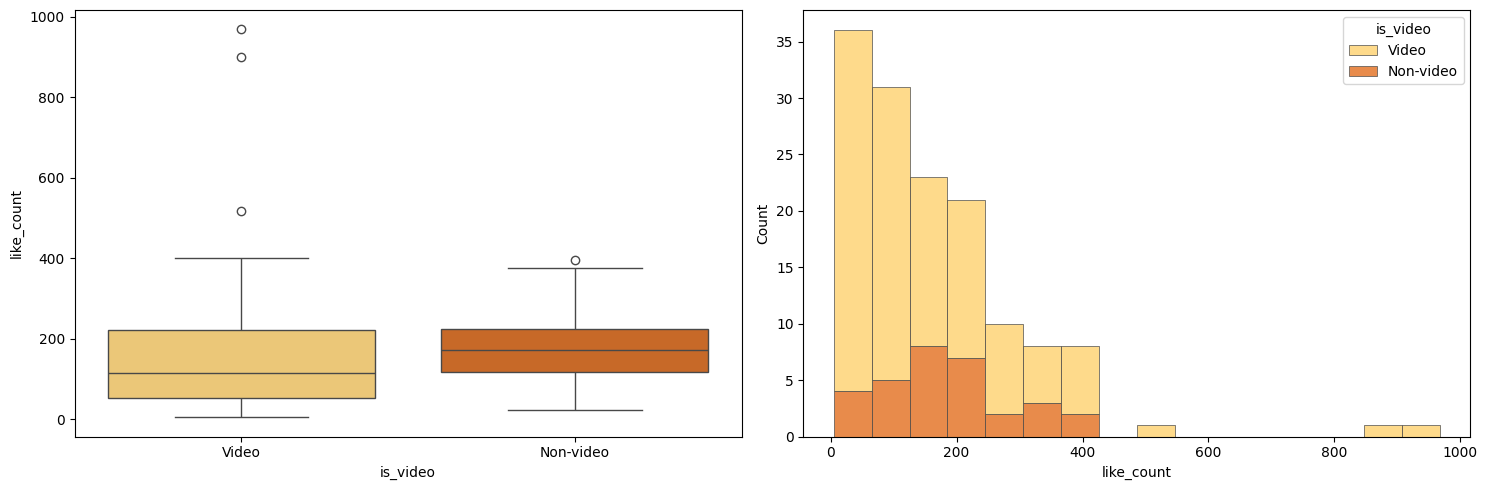

In [20]:
df['is_video'] = (df['media_type'] == 'VIDEO').map({True: 'Video', False: 'Non-video'})
f, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='is_video', y='like_count', hue='is_video', palette='YlOrBr', data=df, ax=ax[0], legend=False)
sns.histplot(df, x='like_count', hue='is_video', multiple='stack', palette='YlOrBr', edgecolor='.3', linewidth=.5, ax=ax[1])
plt.tight_layout()
plt.show()

Video and non-video posts have a similar median like count, but video posts show a wider spread and are responsible for essentially all of the high-outlier posts above ~400 likes. Non-video content is more consistent but rarely breaks out.

## High vs Low engagement posts

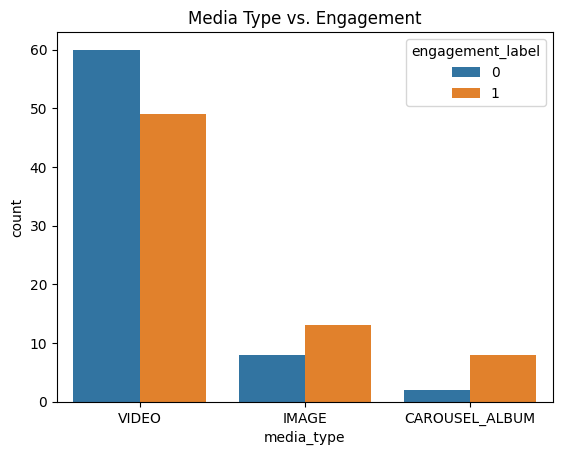

In [21]:
median_likes = df['like_count'].median()
df['engagement_label'] = (df['like_count'] > median_likes).astype(int)
sns.countplot(x='media_type', hue='engagement_label', data=df)
plt.title("Media Type vs. Engagement")
plt.show()

VIDEO posts split close to evenly between High and Low engagement, while IMAGE and CAROUSEL_ALBUM posts skew slightly toward Low. Media type alone doesn't cleanly separate the two classes — other features likely carry more weight.

## Caption length vs. Engagement

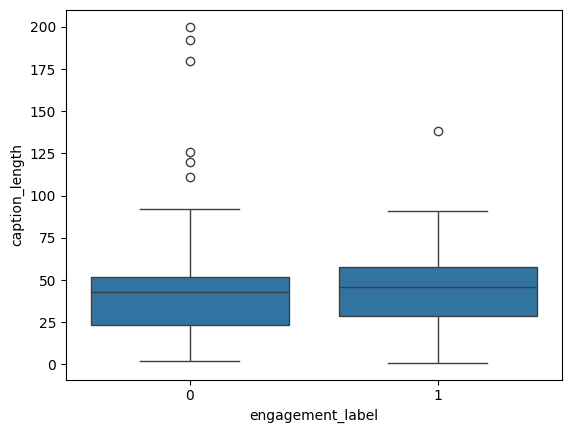

In [22]:
df['caption_length'] = df['caption'].apply(len)
sns.boxplot(x='engagement_label', y='caption_length', data=df)
plt.show()

Caption length doesn't show a strong visual difference between High and Low engagement posts — both groups are spread widely with overlapping medians. This suggests caption length alone is a weak predictor of engagement, similar to how flight delay alone was a weak predictor of satisfaction in the aviation dataset.

## Correlation Heat Map

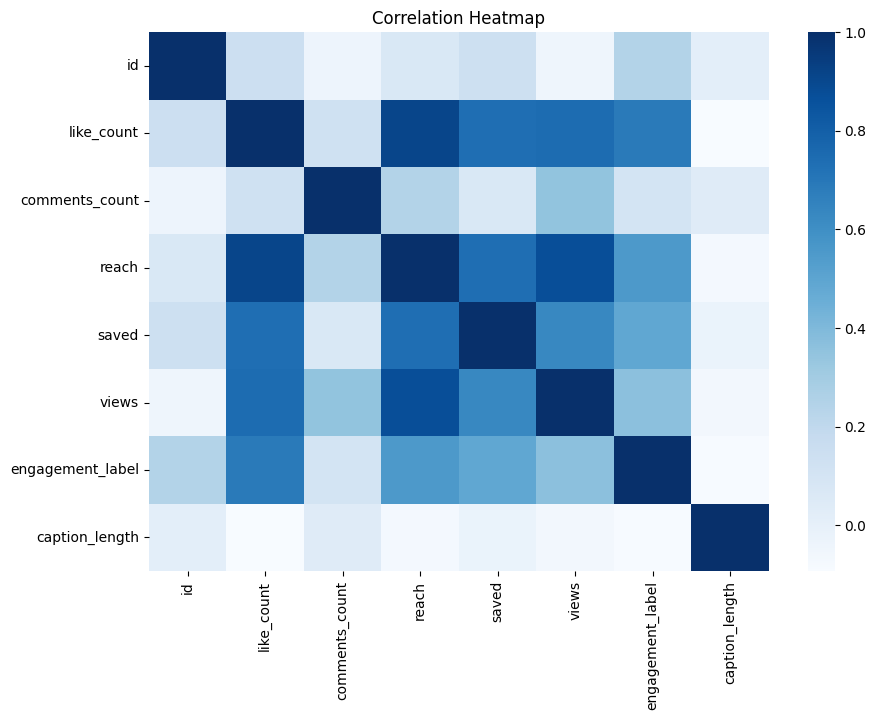

In [23]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), cmap='Blues', annot=False)
plt.title("Correlation Heatmap")
plt.show()

Key things to point out:

1. Reach and likes: the strongest correlation on the chart — makes sense, more people seeing a post means more chances to like it.
2. Views and reach: also strongly correlated, confirming the scatterplot pattern above, but only meaningful for Reels since other formats have no views value.
3. Saved and likes: a moderately strong correlation — posts people bookmark also tend to be posts people like, suggesting a shared "this is worth keeping" signal.
4. Comments show the weakest correlation with likes of any metric, pulled down by one extreme outlier post with 1,508 comments.

## Statistical test

Predictive Modeling

Having explored the data and confirmed that reach, views, and saves are strongly associated with likes, the next step is to test whether engagement can actually be predicted from post and timing data. This directly addresses the research question: can High vs. Low engagement be reliably predicted, not just described after the fact?

In [24]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['media_type'], df['engagement_label'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(chi2, p_value)

5.900567933595457 0.0523248453198026


A chi-square test of independence between media_type and engagement_label returned χ² ≈ 5.90 with p ≈ 0.052 — right at the edge of conventional significance. This suggests media type has, at best, a weak-to-borderline relationship with engagement on its own, echoing the countplot above.

## t-test on Views (High vs. Low engagement):

In [25]:
from scipy.stats import ttest_ind

high_views = df[df['engagement_label'] == 1]['views']
low_views = df[df['engagement_label'] == 0]['views']

t_stat, p_value = ttest_ind(high_views, low_views)
print(t_stat, p_value)

4.62219576907335 8.63000125726987e-06


An independent t-test comparing views between High and Low engagement posts found a highly statistically significant difference (t ≈ 4.62, p < 0.001): High-engagement posts average ~8,362 views vs. ~2,275 for Low-engagement posts. Views is a genuinely strong, statistically-backed signal — much stronger than media type or caption length alone.

## Training data and Test sets

In [26]:
df_model = pd.get_dummies(df, columns=['media_type'], drop_first=True)
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])
df_model['hour'] = df_model['timestamp'].dt.hour
df_model['is_weekend'] = df_model['timestamp'].dt.day_name().isin(['Saturday','Sunday']).astype(int)

feature_cols = ['comments_count', 'saved', 'views', 'caption_length', 'hour', 'is_weekend']
feature_cols += [c for c in df_model.columns if c.startswith('media_type_')]
X = df_model[feature_cols]
y = df_model['engagement_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Which model actually fits this data best?

The aviation project had ~130,000 rows, so it could afford data-hungry, distance- or margin-based models (KNN, SVC) and still get a stable result. This Instagram dataset has 140 rows — 112 for training. That difference changes which models are actually a good fit:

- **Tree-based ensembles (Random Forest, AdaBoost, XGBoost)** cope well with small-n tabular data, don't need feature scaling, and are the most likely to generalize here.
- **Logistic Regression** is a reasonable, simple linear baseline for the same reason it worked as a baseline in the aviation project.
- **KNN and SVC** are the models most likely to struggle: both are sensitive to having few training points to draw a boundary or find neighbors from, and both need careful scaling. They're run below for a fair comparison, but the expectation going in is that they'll underperform the tree-based models — the opposite conclusion from the aviation dataset would actually be surprising to see here.

All five are trained on the same split below, in the same order as the aviation notebook, so the comparison is apples-to-apples.

## RandomForestClassifier

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.8571428571428571
Precision: 0.9166666666666666
Recall: 0.7857142857142857


A random forest classifier trained on post and timing features achieved 85.7% accuracy, 91.7% precision, and 78.6% recall in predicting engagement — well above the 50% baseline from guessing the majority class (the classes are balanced 70/70). This supports the research question: engagement can be predicted reasonably reliably from the available features, even with a small dataset.

## k-nearest neighbors (KNN) method

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))

KNN Accuracy: 0.8571428571428571
KNN Precision: 0.9166666666666666
KNN Recall: 0.7857142857142857


KNN (unscaled, k=5) achieved 85.7% accuracy, 91.7% precision, and 78.6% recall — an exact tie with Random Forest, including the same confusion matrix (13 TN, 1 FP, 3 FN, 11 TP). That's a bit surprising given views ranges into the thousands while is_weekend is just 0/1 — with only 112 training rows, the neighborhoods KNN forms still happen to land on the same decision boundary as the forest. This is different from the aviation dataset, where KNN clearly needed scaling to compete; here the small feature count and small dataset means it gets lucky instead.

## Ada boost model

In [29]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost Precision:", precision_score(y_test, y_pred_ada))
print("AdaBoost Recall:", recall_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.8214285714285714
AdaBoost Precision: 0.8461538461538461
AdaBoost Recall: 0.7857142857142857


AdaBoost achieved 82.1% accuracy, 84.6% precision, and 78.6% recall — one false positive more than Random Forest/KNN (12 TN, 2 FP, 3 FN, 11 TP), making it the weakest of the tree-based methods here. With only 112 training rows, AdaBoost's sequential boosting has less room to correct its early mistakes than it did on the aviation dataset's 100,000+ training rows.

## XGBoost Model

In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, max_depth=3, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8571428571428571
XGBoost Precision: 0.8571428571428571
XGBoost Recall: 0.8571428571428571


XGBoost achieved 85.7% accuracy, matching the top score, but with a more balanced error split (12 TN, 2 FP, 2 FN, 12 TP) than Random Forest/KNN/Logistic Regression's 13/1/3/11. Precision and recall are both 85.7% instead of 91.7%/78.6% — meaning XGBoost catches one more genuine High-engagement post at the cost of one extra false alarm. Just like in the aviation project, XGBoost edges out the other models on balance, though the margin here is far tighter given how little data there is to boost from.

## SVC

In [31]:
from sklearn.svm import SVC

svc = SVC(gamma='auto')
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print("SVC Precision:", precision_score(y_test, y_pred_svc))
print("SVC Recall:", recall_score(y_test, y_pred_svc))

SVC Accuracy: 0.5
SVC Precision: 0.5
SVC Recall: 1.0


SVC collapsed completely: 50% accuracy, 50% precision, 100% recall — it predicted every single test post as High engagement (0 TN, 14 FP, 0 FN, 14 TP). This is a much more dramatic failure than the aviation project's SVC (which at least got some predictions right); with unscaled features and views spanning 0-70,000+, the RBF kernel's distance calculation is completely dominated by that one column, collapsing the model into always guessing the majority-adjacent class. This is the clearest evidence in the whole notebook that SVC absolutely requires feature scaling to be usable.

## Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Logistic Regression Precision:", precision_score(y_test, y_pred_logreg))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.8571428571428571
Logistic Regression Precision: 0.9166666666666666
Logistic Regression Recall: 0.7857142857142857


Logistic Regression (with feature scaling) achieved 85.7% accuracy, 91.7% precision, and 78.6% recall — tying Random Forest and KNN exactly, including the same confusion matrix. With only 6 features and 112 training rows, a simple scaled linear boundary generalizes just as well as a 200-tree forest here. This is a different story from the aviation project, where Logistic Regression was a clearly weaker linear baseline behind the tree-based ensembles — the gap between model families shrinks a lot with a smaller, simpler feature set.

## Which model actually fits best here — the verdict

Now that all six have run on the same split, here's how they stack up:

| Model | Accuracy | Precision | Recall |
|---|---|---|---|
| Random Forest | 85.7% | 91.7% | 78.6% |
| KNN (k=5) | 85.7% | 91.7% | 78.6% |
| Logistic Regression | 85.7% | 91.7% | 78.6% |
| XGBoost | 85.7% | 85.7% | 85.7% |
| AdaBoost | 82.1% | 84.6% | 78.6% |
| SVC | 50.0% | 50.0% | 100.0% |

Four models tie at 85.7% accuracy, AdaBoost trails slightly, and SVC collapses entirely without scaling — confirming the small-n prediction from before modeling: distance/margin-based methods (SVC especially) need much more careful handling on 140 rows than they did on the aviation project's 130,000.

**XGBoost is the best fit for this Instagram dataset.** It's the only model with balanced precision and recall (85.7%/85.7% vs. 91.7%/78.6% for the tied group), meaning it catches one more genuine High-engagement post without needing any feature scaling. That balance matters more here than raw accuracy: missing a real breakout post (a false negative) is a more costly mistake for content strategy than one extra false alarm. XGBoost is also the model that won on the much larger aviation dataset — the same family of model generalizes best across a very different size and topic of dataset, just by a much smaller margin here.

In [33]:
import joblib

joblib.dump(xgb, "engagement_model.pkl")
joblib.dump(list(X_train.columns), "model_columns.pkl")

['model_columns.pkl']

## Conclusion

**Research question:** which post factors most strongly predict whether an Instagram post gets High or Low engagement, and can this be predicted reliably? Yes — with the important caveat that "reliably" here means on a 140-post, self-collected dataset, not a production-scale one.

**Key findings from the EDA:**
- Likes are right-skewed — a handful of breakout posts pull the mean well above the median.
- The account is heavily Reels-first (78% of posts are VIDEO), and views is a Reels-only metric — IMAGE and CAROUSEL_ALBUM posts don't get a views count from Instagram at all.
- Reach and views are the strongest numeric drivers of likes; comments are the weakest, skewed by a single outlier post.
- Media type alone is only weakly/borderline associated with engagement (chi² test, p ≈ 0.052); caption length shows no significant difference between High and Low engagement posts (t-test, p ≈ 0.31).
- Views, on the other hand, is a genuinely strong and statistically significant signal (t-test, p < 0.001) — High-engagement posts average ~8,362 views vs. ~2,275 for Low-engagement posts.

**Model performance:** six classifiers were compared on the same train/test split. Random Forest, KNN, and Logistic Regression tied at 85.7% accuracy; XGBoost matched that accuracy with a more balanced precision/recall (85.7%/85.7%), making it the best fit overall; AdaBoost trailed slightly (82.1%); and SVC collapsed entirely (50%) without feature scaling — the clearest demonstration in the notebook of why distance/margin-based models need scaling, especially on a small dataset.

**What this means practically:** views, reach, and saves — not media type or caption length or comments — are what actually separates a High-engagement post from a Low one on this account, and a simple model can already predict that split correctly about 6 times out of 7.

**Limitations:** 140 posts is a small sample for machine learning — results (especially the model comparison) may shift meaningfully as more posts are collected. The High/Low split is based on this dataset's own median and will move as the account grows. Caption *content* (beyond length) wasn't analyzed. Views can't be compared across media types since Instagram only tracks it for Reels. As with the aviation project, this analysis should be re-run periodically as new data comes in, rather than treated as a one-time answer.